# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/XGBOOST'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

In [5]:
FEATURES = [
    'year', 'month', 'day_of_week', 'day_of_year', 'week_of_year',
    'is_weekend', 'is_holiday', 'tavg', 'prcp',
    'is_after_weekend', 'is_after_holiday', 'is_after_gap',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std', 'rolling_30_mean',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

TARGET = 'total_tonnes'

# Model Definition - XGBoost

In [6]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error — robust to zero values."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def run_xgboost_prediction(df, dataset_name, dataset_code, dataset_number, features, split_days=90, n_splits=3, TARGET='total_tonnes', VIS_DIR='.'):
    """
    Train XGBoost with rolling-origin validation (no fine-tuning).
    Uses walk-forward prediction: dynamically updates lag values.
    Plots are generated ONLY for the best split (lowest sMAPE).
    """
    print(f"\n{'='*100}")
    print(f"XGBOOST PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # feature filtering
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"Note: Missing features (skipped): {missing_features}")

    # dropping NaN rows in target
    df_valid = df[df[TARGET].notna()].reset_index(drop=True)
    print(f"Total rows: {len(df)}, Valid (non-NaN target): {len(df_valid)}")

    # ============================================================
    # ROLLING-ORIGIN VALIDATION
    # ============================================================
    split_results = []
    total_needed = split_days * n_splits

    if len(df_valid) < total_needed + 100:
        print(f"WARNING: Not enough data for {n_splits} splits of {split_days} days.")
        print(f"Reducing to 2 splits.")
        n_splits = 2

    print(f"\nRolling-origin validation: {n_splits} splits of {split_days} days each")

    best_smape = float('inf')
    best_split_data = None
    best_model = None

    for split_idx in range(n_splits):
        offset = (n_splits - 1 - split_idx) * split_days
        if offset == 0:
            train = df_valid.iloc[:-split_days].copy()
            test = df_valid.iloc[-split_days:].copy()
        else:
            train = df_valid.iloc[:-(offset + split_days)].copy()
            test = df_valid.iloc[-(offset + split_days):-offset].copy()

        print(f"\n--- Split {split_idx+1}/{n_splits} ---")
        print(f"Train: {len(train)} days ({train['date'].min().date()} → {train['date'].max().date()})")
        print(f"Test:  {len(test)} days ({test['date'].min().date()} → {test['date'].max().date()})")

        # model fit
        X_train = train[available_features]
        y_train = train[TARGET]

        model = xgb.XGBRegressor(
            random_state=2,
            objective='reg:squarederror'
        )
        model.fit(X_train, y_train, verbose=False)

        # walk-forward prediction on test set - no negatives
        predictions = []
        test_copy = test.copy()

        for i in range(len(test_copy)):
            row = test_copy.iloc[i:i+1][available_features]
            pred = model.predict(row)[0]
            pred = max(pred, 0)
            predictions.append(pred)

            # update lag features for next predictions
            idx = test_copy.index[i]
            if i + 1 < len(test_copy):
                next_idx = test_copy.index[i + 1]
                if 'lag_1' in available_features:
                    test_copy.loc[next_idx, 'lag_1'] = pred
                if 'lag_2' in available_features and i + 2 < len(test_copy):
                    test_copy.loc[test_copy.index[min(i+2, len(test_copy)-1)], 'lag_2'] = pred

        y_true = test[TARGET].values
        y_pred = np.array(predictions)

        # metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape_val = smape(y_true, y_pred)

        split_results.append({'mae': mae, 'rmse': rmse, 'smape': smape_val})
        print(f"MAE: {mae:.2f}t | RMSE: {rmse:.2f}t | sMAPE: {smape_val:.2f}%")

        # track the best split
        if smape_val < best_smape:
            best_smape = smape_val
            best_model = model
            best_split_data = {
                'split_idx': split_idx + 1,
                'train': train,
                'test': test,
                'y_true': y_true,
                'y_pred': y_pred,
                'mae': mae,
                'rmse': rmse,
                'smape': smape_val
            }


    # ============================================================
    # AVERAGE METRICS ACROSS SPLITS
    # ============================================================
    avg_mae = np.mean([r['mae'] for r in split_results])
    avg_rmse = np.mean([r['rmse'] for r in split_results])
    avg_smape = np.mean([r['smape'] for r in split_results])

    print(f"\n--- AVERAGE ACROSS {n_splits} SPLITS ---")
    print(f"MAE:   {avg_mae:.2f} tonnes")
    print(f"RMSE:  {avg_rmse:.2f} tonnes")
    print(f"sMAPE: {avg_smape:.2f}%")
    print(f"Best split was Split {best_split_data['split_idx']} (sMAPE: {best_split_data['smape']:.2f}%)")


    # ============================================================
    # PLOT — BEST SPLIT ONLY
    # ============================================================
    train_plot = best_split_data['train']
    test_plot = best_split_data['test']
    y_true_plot = best_split_data['y_true']
    y_pred_plot = best_split_data['y_pred']


    # --- Plot 2X1: Actual vs Predicted (test period) - XGBoost ---
    fig, ax = plt.subplots(figsize=(16, 6))

    context = train_plot.iloc[-30:]
    ax.plot(context['date'], context[TARGET], color='steelblue',
            linewidth=1, label='Training Data (last 30 days)')

    ax.plot(test_plot['date'], y_true_plot, color='steelblue',
            linewidth=1.5, label='Actual (Test)')

    ax.plot(test_plot['date'], y_pred_plot, color='red',
            linewidth=1.5, linestyle='--', label='XGBoost Forecast')

    ax.axvline(x=test_plot['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f"XGBoost Forecast vs Actual — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f"Best Split Metrics:\nMAE: {best_split_data['mae']:.2f}t\nRMSE: {best_split_data['rmse']:.2f}t\nsMAPE: {best_split_data['smape']:.1f}%",
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'2{dataset_number}1_xgb_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 2X2: Zoom on first 30 days of test - XGBoost ---
    fig, ax = plt.subplots(figsize=(14, 5))

    zoom_days = min(30, split_days)
    ax.plot(test_plot['date'].iloc[:zoom_days], y_true_plot[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')

    ax.plot(test_plot['date'].iloc[:zoom_days], y_pred_plot[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='XGBoost')

    ax.set_title(f"XGBoost Forecast Zoom — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'2{dataset_number}2_xgb_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 2X3: Feature importance - XGBoost ---
    fig, ax = plt.subplots(figsize=(10, 8))

    importance = pd.Series(best_model.feature_importances_, index=available_features)
    importance = importance.sort_values(ascending=True)
    importance.tail(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

    ax.set_title(f"Top 15 Feature Importance — {dataset_name} (Best Model)", fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'2{dataset_number}3_xgb_feature_importance_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'dataset': dataset_name,
        'model': 'XGBoost',
        'mae': round(avg_mae, 2),
        'rmse': round(avg_rmse, 2),
        'smape': round(avg_smape, 2),
        'n_splits': n_splits,
        'split_days': split_days,
        'split_details': split_results
    }

# Model Prediction - XGBoost


XGBOOST PREDICTION — Boralesgamuwa UC (Sri Lanka)
Total rows: 2527, Valid (non-NaN target): 2387

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 2117 days (2012-01-31 → 2018-03-26)
Test:  90 days (2018-03-28 → 2018-06-28)
MAE: 8.07t | RMSE: 10.19t | sMAPE: 29.90%

--- Split 2/3 ---
Train: 2207 days (2012-01-31 → 2018-06-28)
Test:  90 days (2018-06-29 → 2018-09-29)
MAE: 6.13t | RMSE: 8.38t | sMAPE: 25.30%

--- Split 3/3 ---
Train: 2297 days (2012-01-31 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
MAE: 6.92t | RMSE: 9.11t | sMAPE: 27.25%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   7.04 tonnes
RMSE:  9.23 tonnes
sMAPE: 27.48%
Best split was Split 2 (sMAPE: 25.30%)


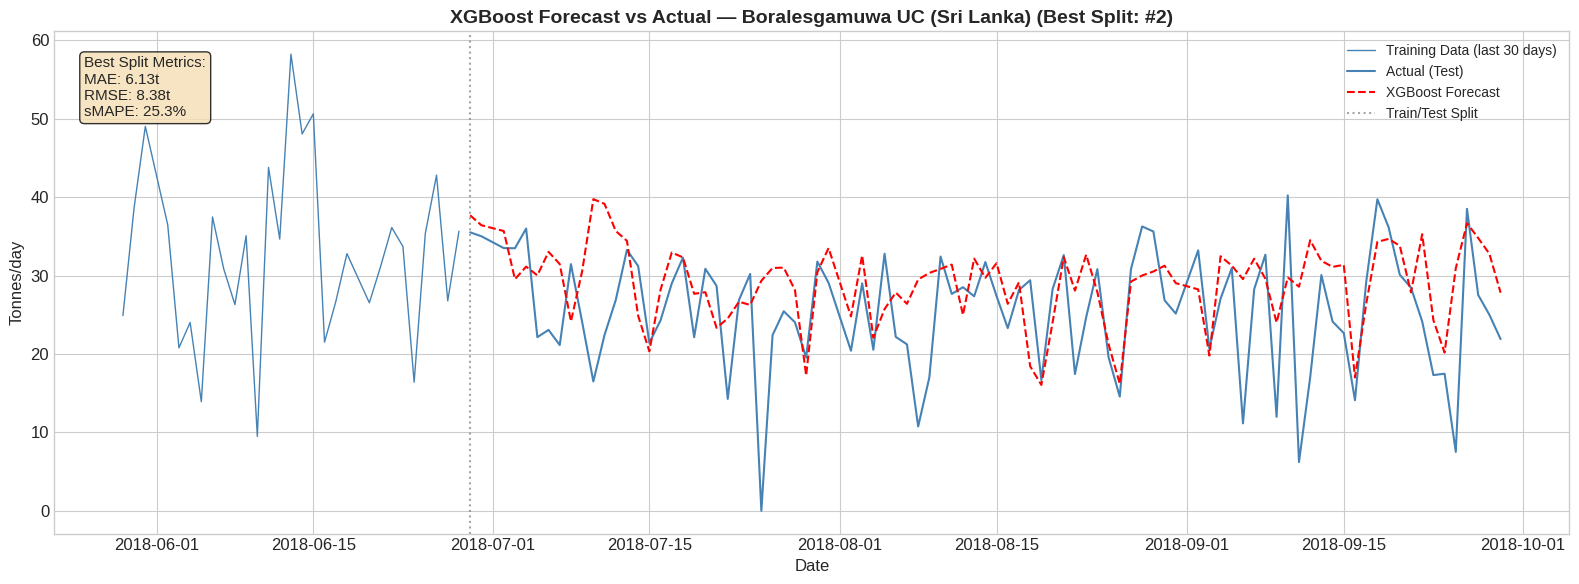

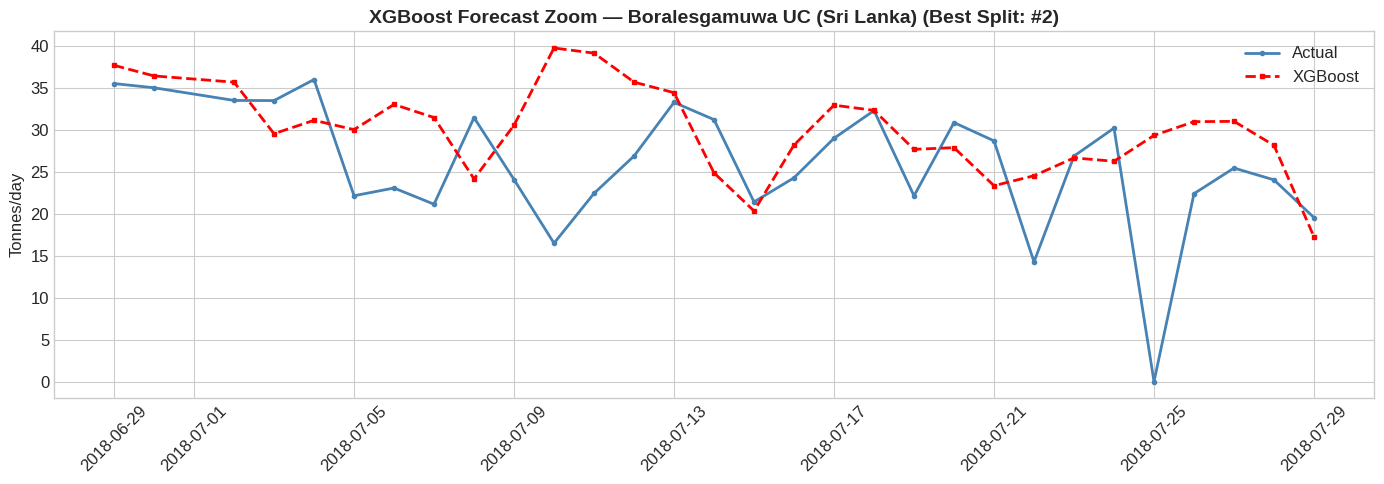

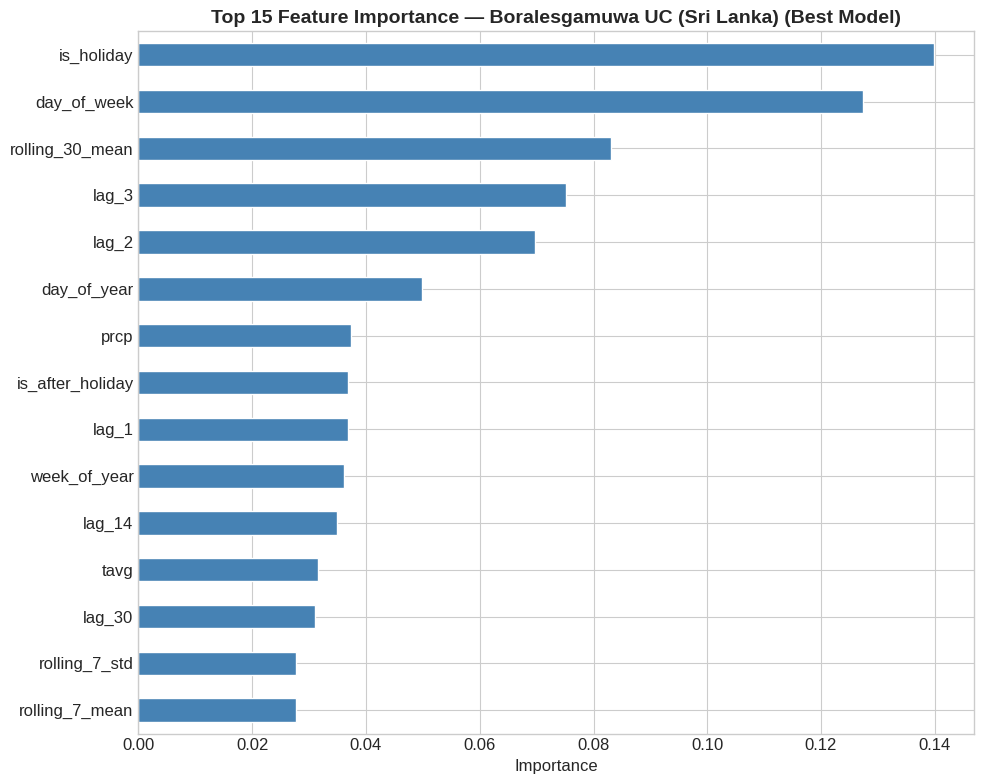


XGBOOST PREDICTION — Dehiwala MC (Sri Lanka)
Total rows: 1431, Valid (non-NaN target): 1403

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1133 days (2012-01-31 → 2015-03-28)
Test:  90 days (2015-03-29 → 2015-07-01)
MAE: 26.71t | RMSE: 33.21t | sMAPE: 18.98%

--- Split 2/3 ---
Train: 1223 days (2012-01-31 → 2015-07-01)
Test:  90 days (2015-07-02 → 2015-09-29)
MAE: 37.37t | RMSE: 53.53t | sMAPE: 31.21%

--- Split 3/3 ---
Train: 1313 days (2012-01-31 → 2015-09-29)
Test:  90 days (2015-09-30 → 2015-12-31)
MAE: 25.91t | RMSE: 34.74t | sMAPE: 20.82%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   30.00 tonnes
RMSE:  40.49 tonnes
sMAPE: 23.67%
Best split was Split 1 (sMAPE: 18.98%)


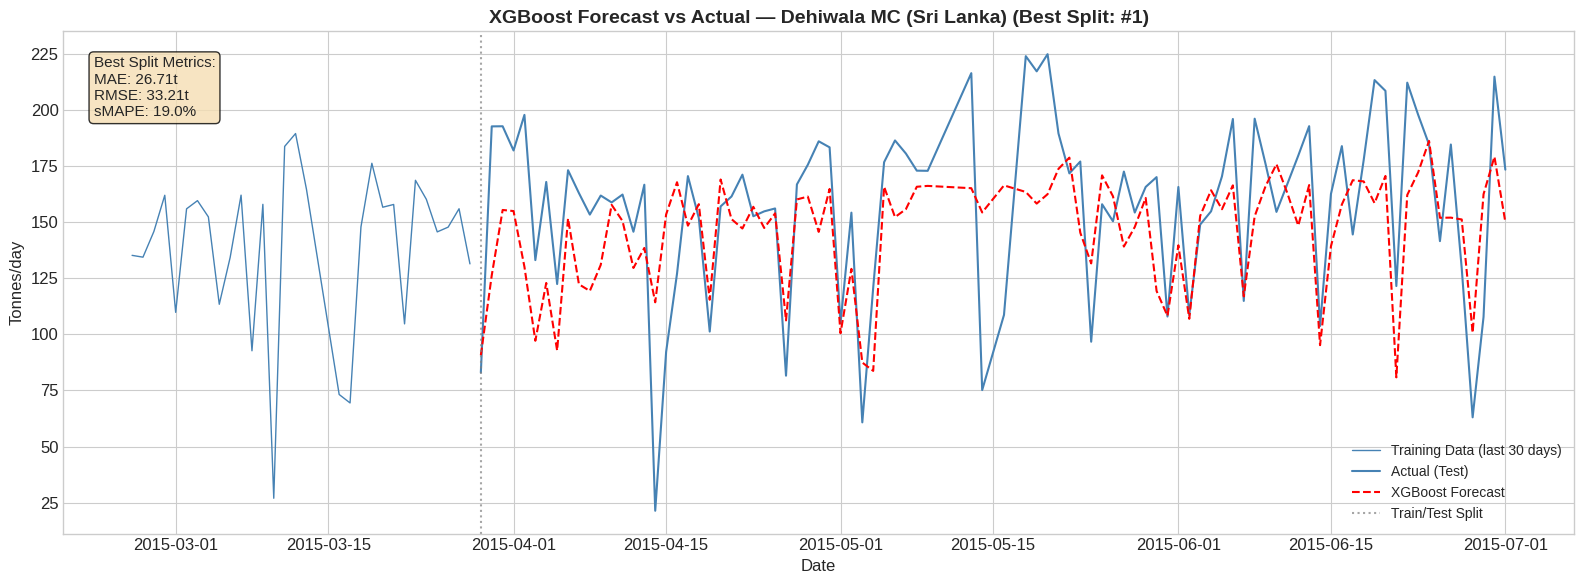

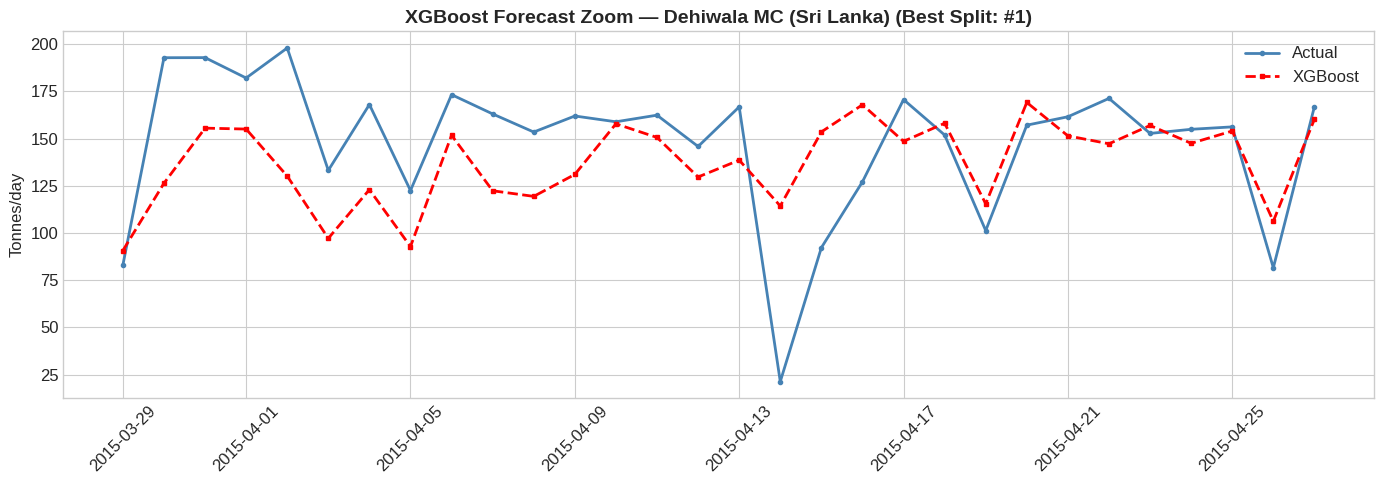

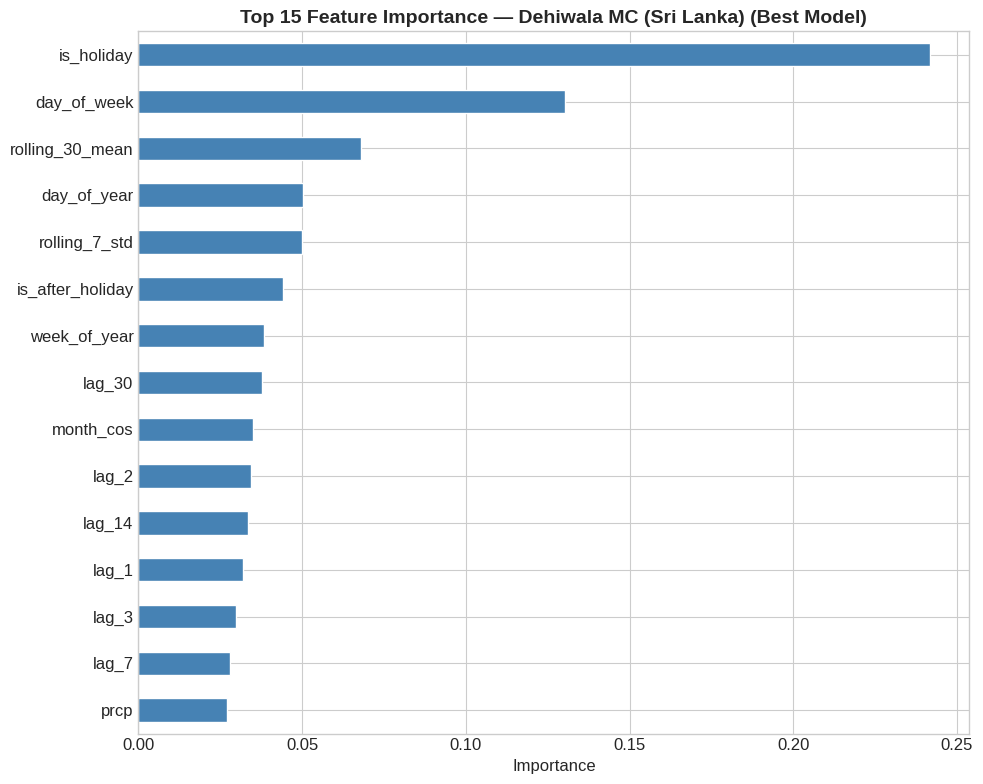


XGBOOST PREDICTION — Homagama PS (Sri Lanka)
Total rows: 2526, Valid (non-NaN target): 2038

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1768 days (2012-02-02 → 2018-03-21)
Test:  90 days (2018-03-22 → 2018-06-25)
MAE: 12.06t | RMSE: 15.78t | sMAPE: 35.03%

--- Split 2/3 ---
Train: 1858 days (2012-02-02 → 2018-06-25)
Test:  90 days (2018-06-26 → 2018-09-29)
MAE: 11.12t | RMSE: 14.84t | sMAPE: 33.82%

--- Split 3/3 ---
Train: 1948 days (2012-02-02 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
MAE: 12.65t | RMSE: 16.24t | sMAPE: 37.15%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   11.94 tonnes
RMSE:  15.62 tonnes
sMAPE: 35.33%
Best split was Split 2 (sMAPE: 33.82%)


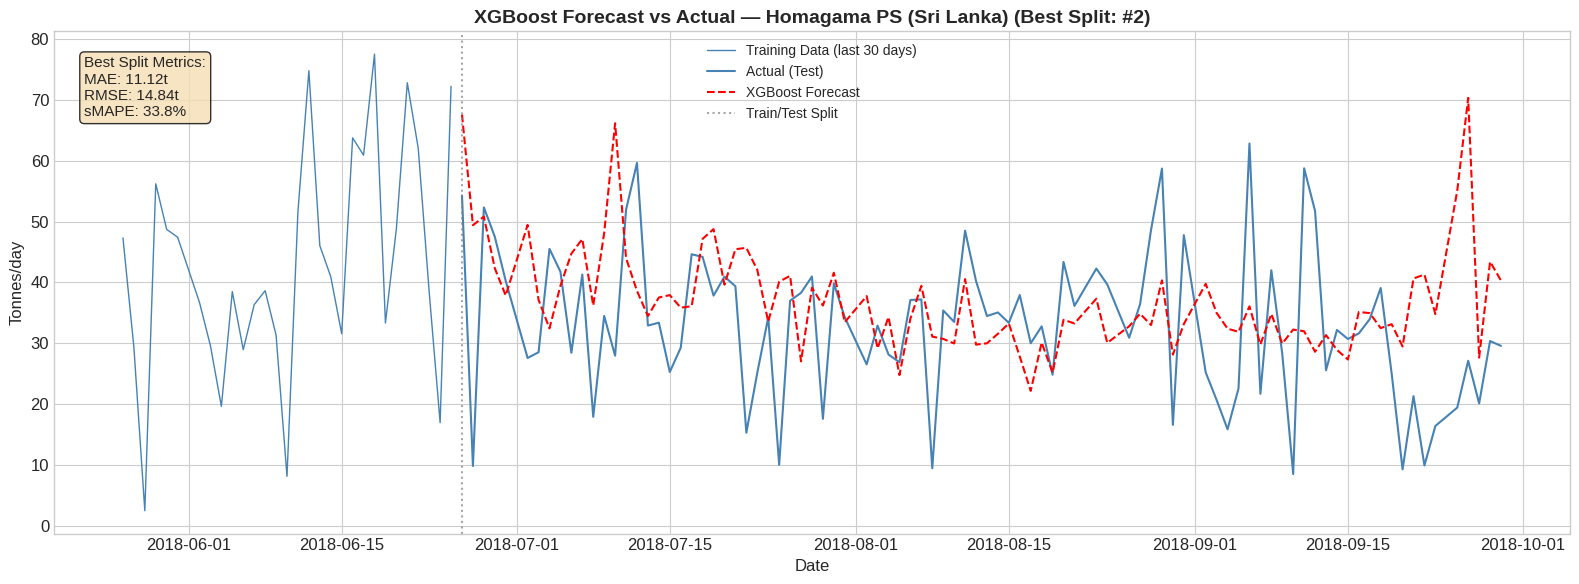

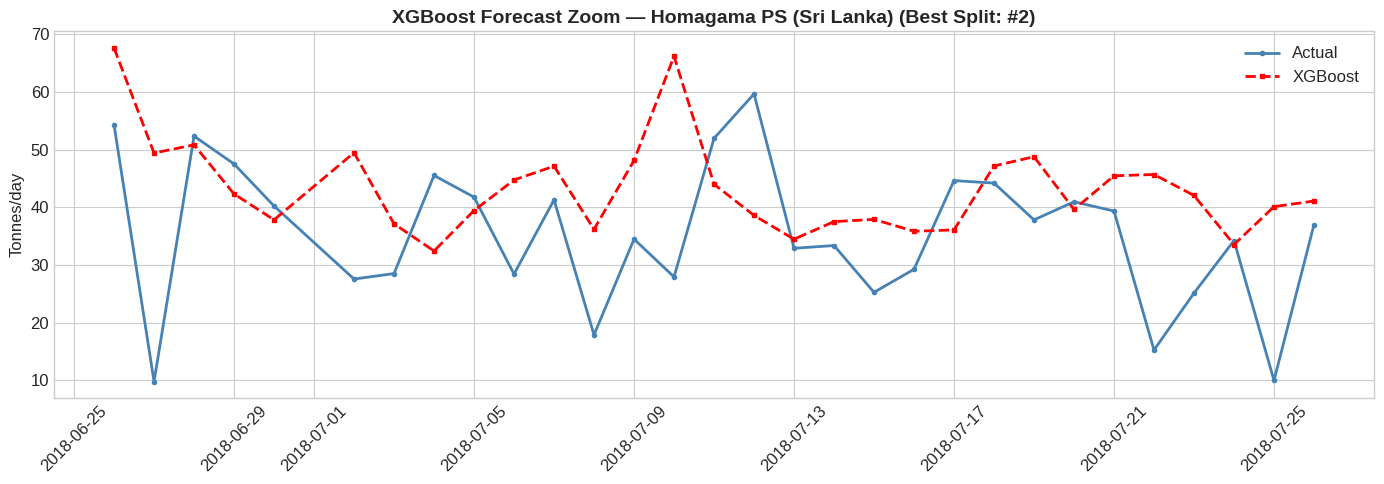

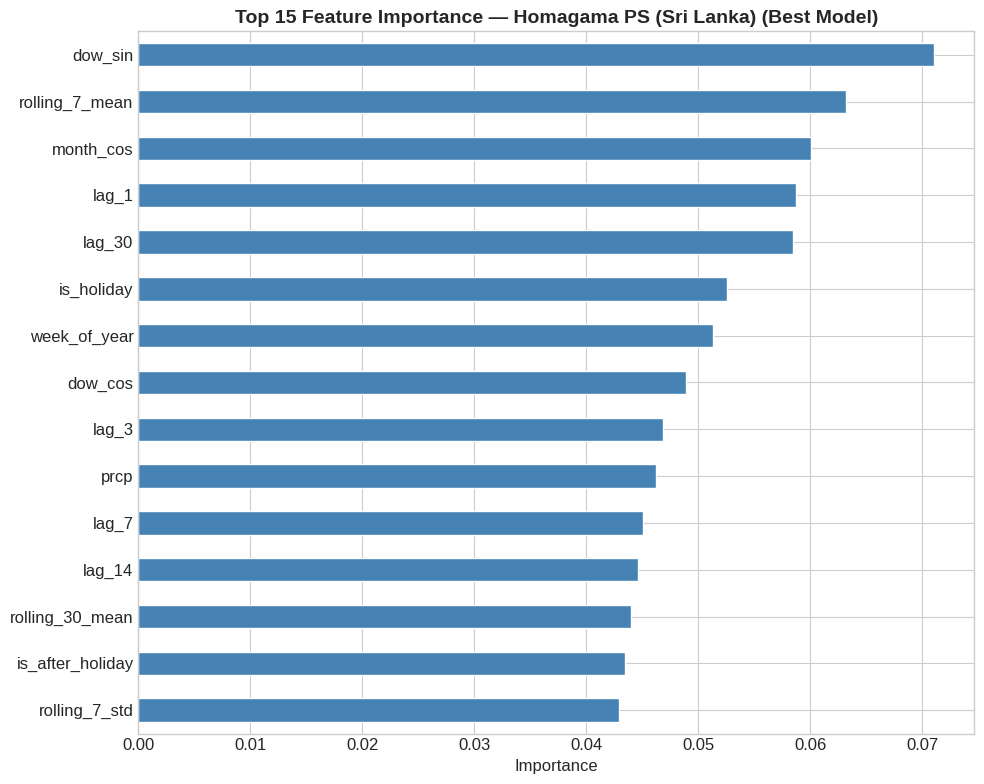


XGBOOST PREDICTION — Moratuwa MC (Sri Lanka)
Total rows: 1411, Valid (non-NaN target): 1278

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1008 days (2015-01-31 → 2018-02-26)
Test:  90 days (2018-02-27 → 2018-06-03)
MAE: 17.79t | RMSE: 23.68t | sMAPE: 26.79%

--- Split 2/3 ---
Train: 1098 days (2015-01-31 → 2018-06-03)
Test:  90 days (2018-06-04 → 2018-09-08)
MAE: 16.59t | RMSE: 21.54t | sMAPE: 23.74%

--- Split 3/3 ---
Train: 1188 days (2015-01-31 → 2018-09-08)
Test:  90 days (2018-09-09 → 2018-12-11)
MAE: 21.86t | RMSE: 27.28t | sMAPE: 32.30%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   18.74 tonnes
RMSE:  24.16 tonnes
sMAPE: 27.61%
Best split was Split 2 (sMAPE: 23.74%)


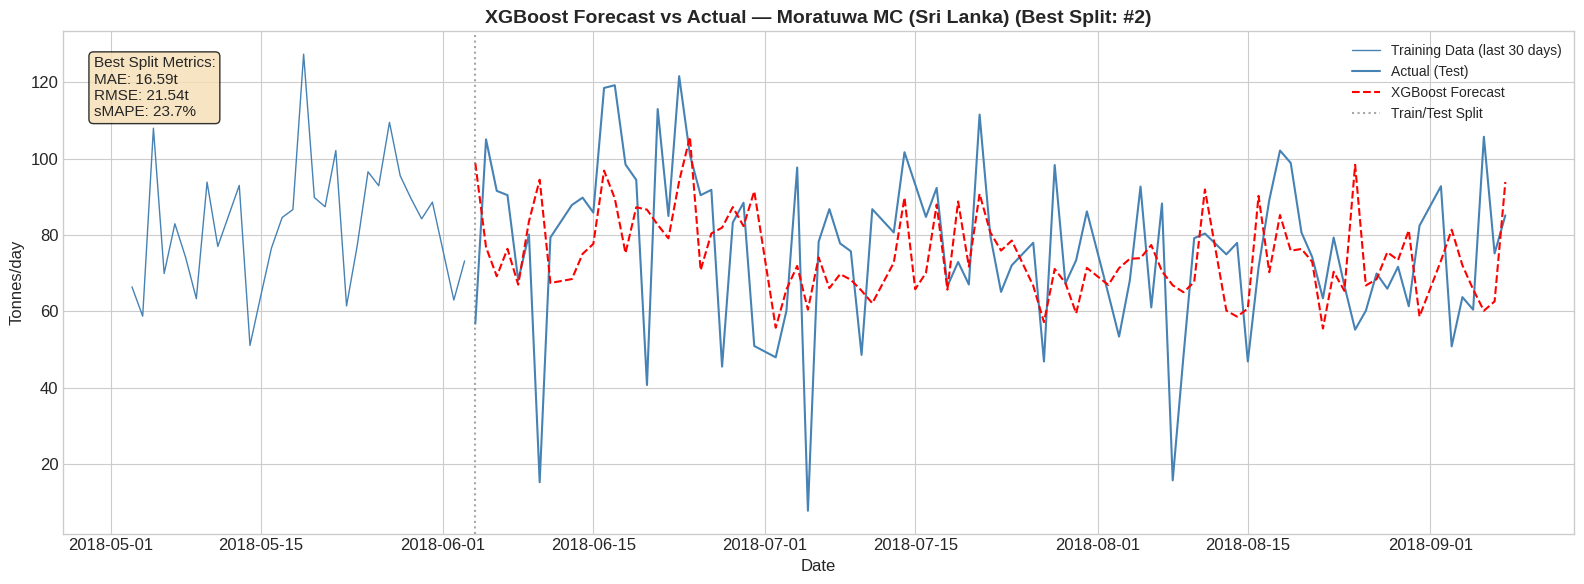

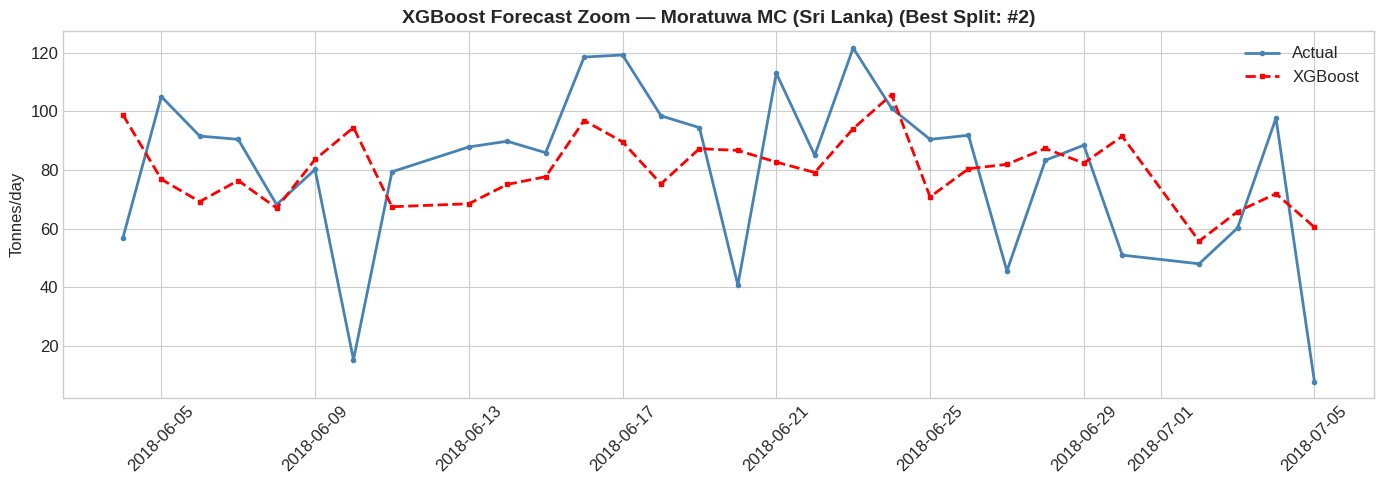

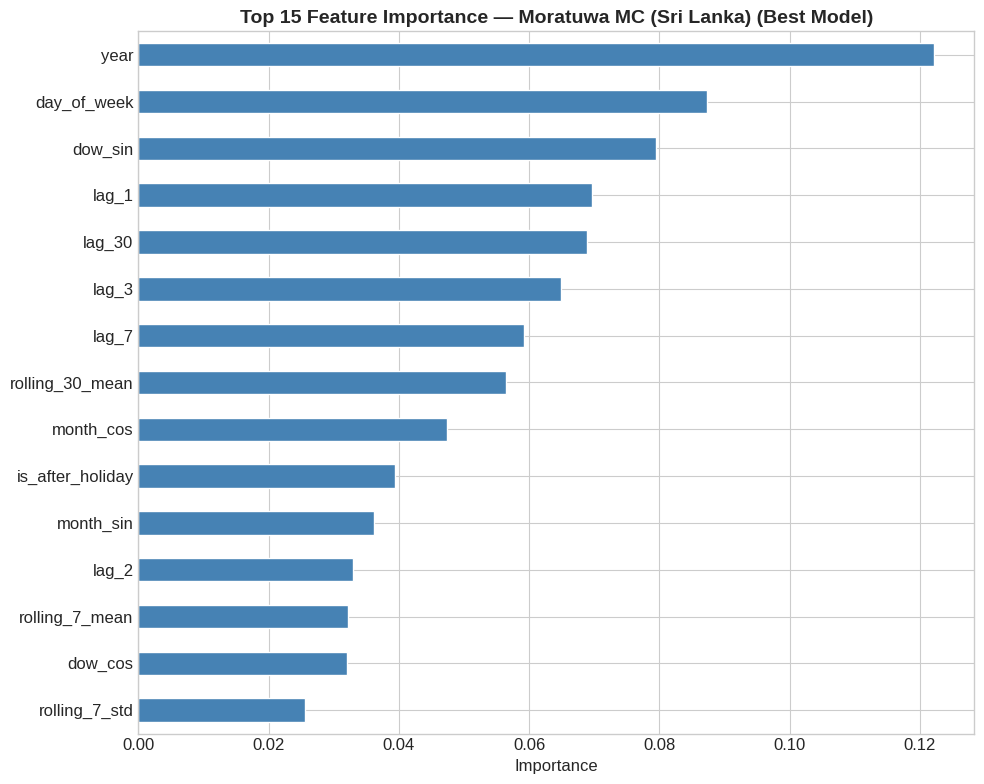


XGBOOST PREDICTION — Austin TX (USA)
Total rows: 5813, Valid (non-NaN target): 5803

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 5533 days (2005-02-01 → 2020-04-04)
Test:  90 days (2020-04-05 → 2020-07-03)
MAE: 135.17t | RMSE: 201.10t | sMAPE: 50.40%

--- Split 2/3 ---
Train: 5623 days (2005-02-01 → 2020-07-03)
Test:  90 days (2020-07-04 → 2020-10-01)
MAE: 88.74t | RMSE: 127.24t | sMAPE: 41.94%

--- Split 3/3 ---
Train: 5713 days (2005-02-01 → 2020-10-01)
Test:  90 days (2020-10-02 → 2020-12-31)
MAE: 213.61t | RMSE: 404.76t | sMAPE: 42.06%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   145.84 tonnes
RMSE:  244.37 tonnes
sMAPE: 44.80%
Best split was Split 2 (sMAPE: 41.94%)


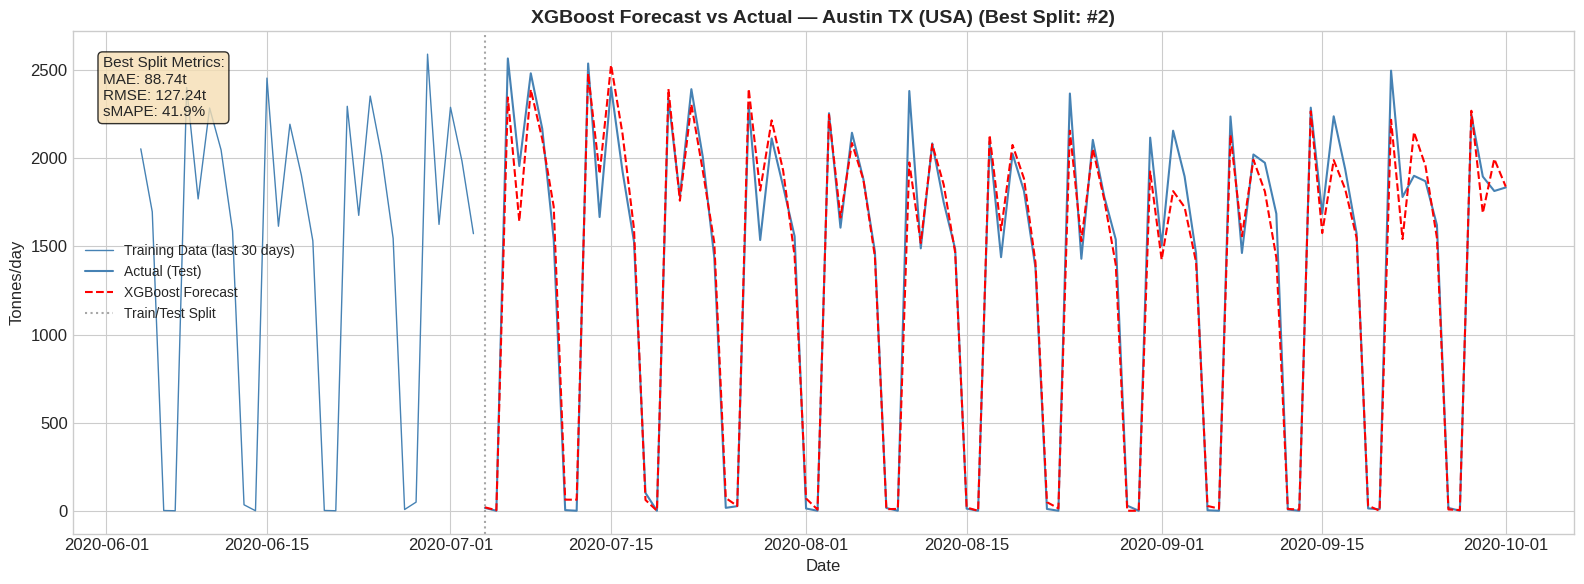

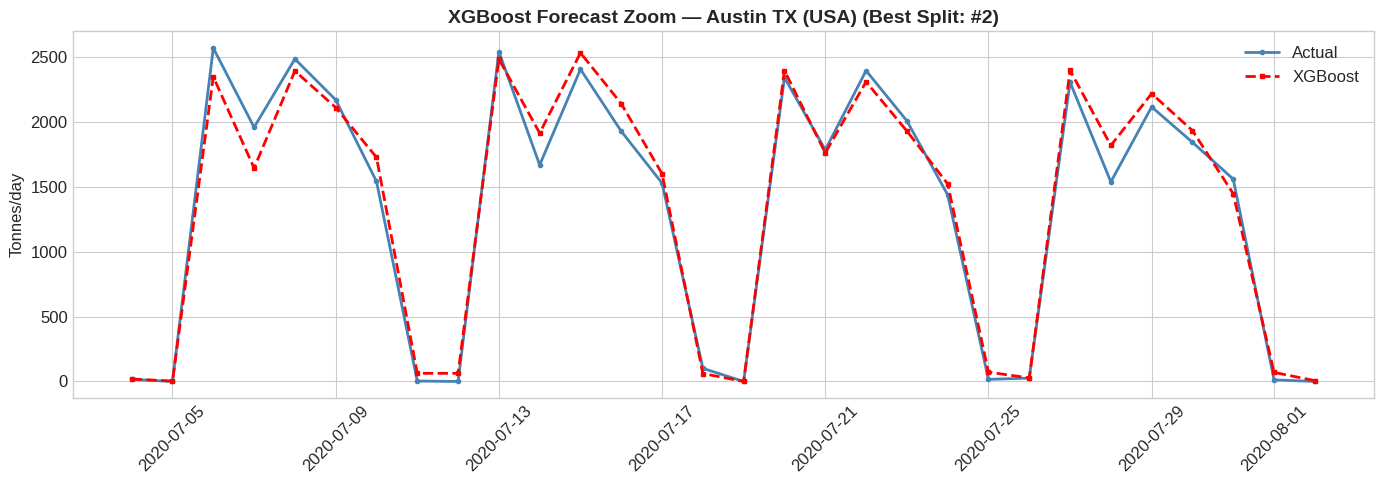

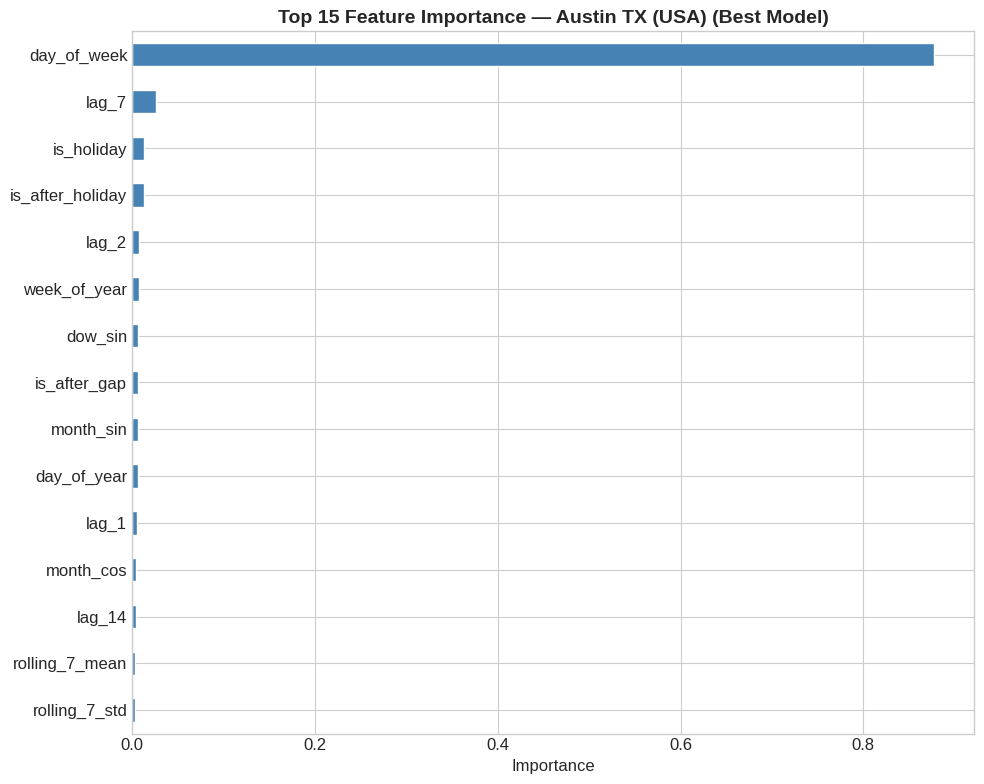


XGBOOST PREDICTION — Ballarat (Australia)
Total rows: 4717, Valid (non-NaN target): 4703

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 4433 days (2001-02-01 → 2013-04-03)
Test:  90 days (2013-04-04 → 2013-07-02)
MAE: 6.39t | RMSE: 9.58t | sMAPE: 38.99%

--- Split 2/3 ---
Train: 4523 days (2001-02-01 → 2013-07-02)
Test:  90 days (2013-07-03 → 2013-10-01)
MAE: 6.47t | RMSE: 10.75t | sMAPE: 48.12%

--- Split 3/3 ---
Train: 4613 days (2001-02-01 → 2013-10-01)
Test:  90 days (2013-10-02 → 2013-12-31)
MAE: 7.61t | RMSE: 12.06t | sMAPE: 43.23%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   6.82 tonnes
RMSE:  10.80 tonnes
sMAPE: 43.45%
Best split was Split 1 (sMAPE: 38.99%)


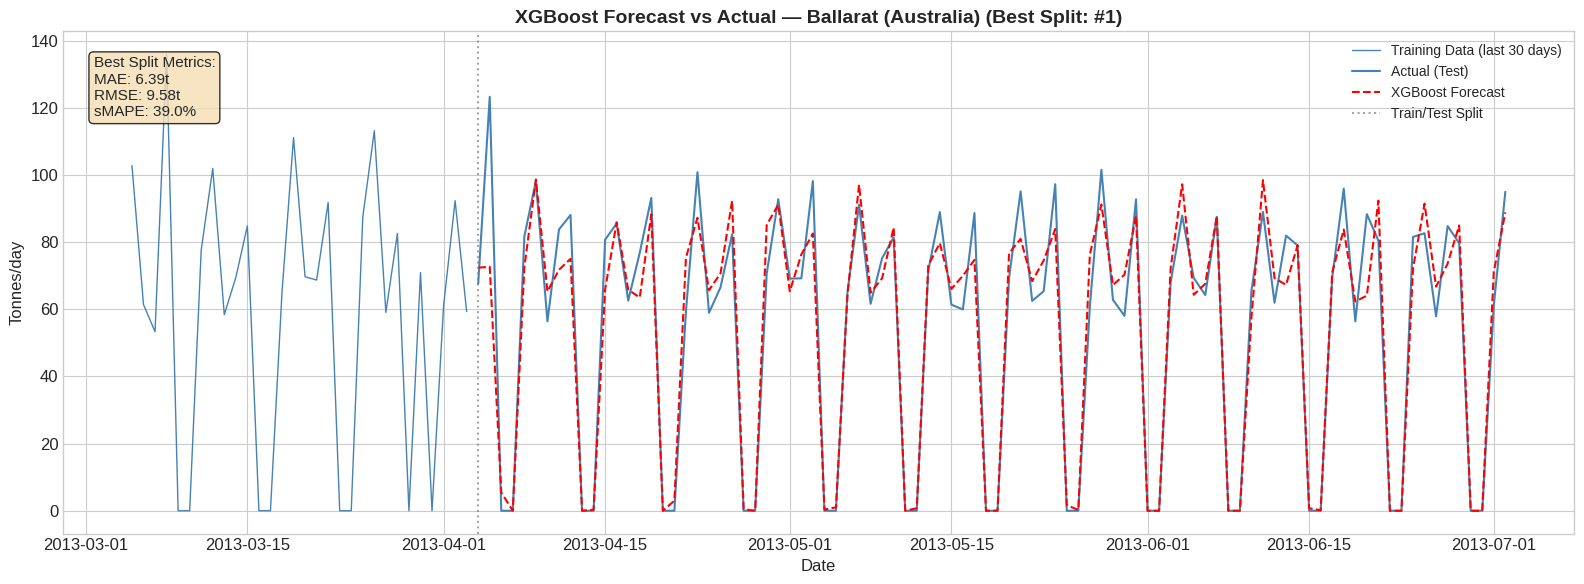

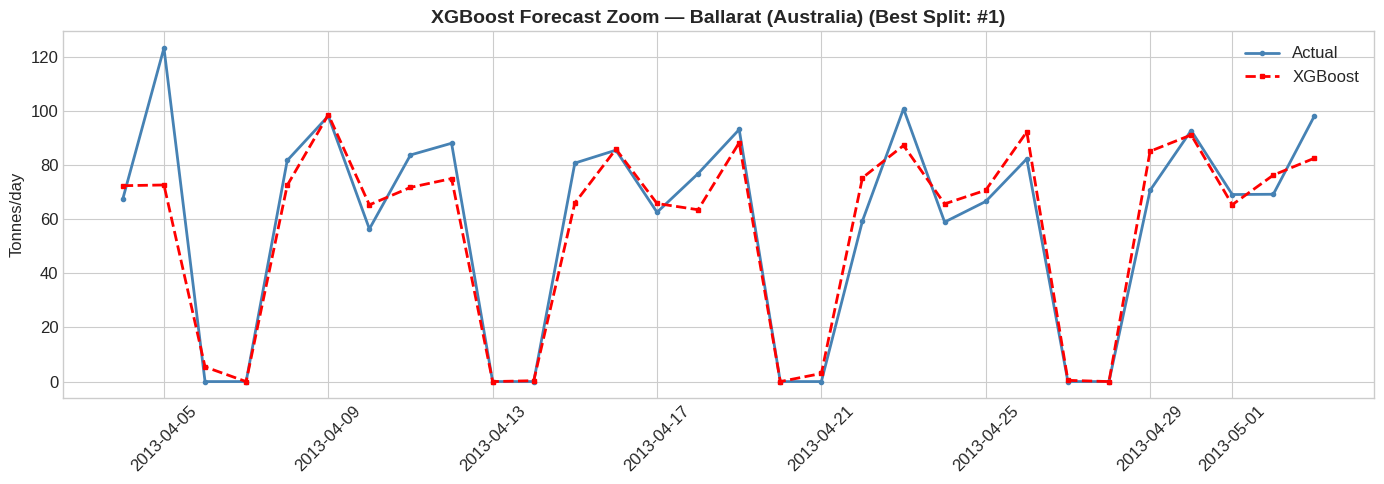

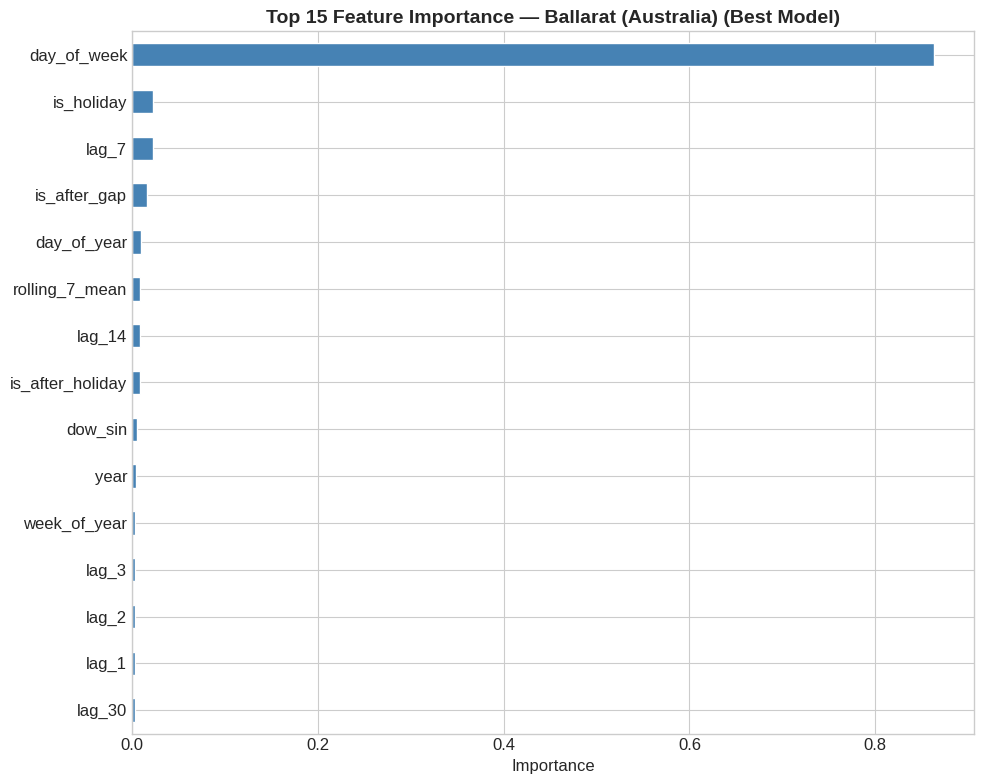

In [7]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_xgboost_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            features = FEATURES,
            split_days = 90,
            n_splits = 3,
            VIS_DIR = VIS_DIR
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [8]:
print("\n" + "=" * 100)
print("XGBOOST RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\nValidation: Rolling-origin with {all_results[0]['n_splits']} splits of {all_results[0]['split_days']} days")
print(f"Metrics are AVERAGED across splits.")
print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'sMAPE (%)':>9s}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['smape']:>8.2f}%")

# average
print("-" * 65)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['smape'].mean():>8.2f}%")

# per-split detail
print(f"\n--- Per-split details ---")
for _, row in results_df.iterrows():
    print(f"\n{row['dataset']}:")
    for j, s in enumerate(row['split_details']):
        print(f"  Split {j+1}: MAE={s['mae']:.2f}t, RMSE={s['rmse']:.2f}t, sMAPE={s['smape']:.2f}%")


# save results
results_df.to_csv(os.path.join(RES_DIR, 'xgboost_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/xgboost_results.csv")


XGBOOST RESULTS SUMMARY — ALL DATASETS

Validation: Rolling-origin with 3 splits of 90 days
Metrics are AVERAGED across splits.

Dataset                        |  MAE (t) |  RMSE (t) | sMAPE (%)
-----------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     7.04 |      9.23 |    27.48%
Dehiwala MC (Sri Lanka)        |    30.00 |     40.49 |    23.67%
Homagama PS (Sri Lanka)        |    11.94 |     15.62 |    35.33%
Moratuwa MC (Sri Lanka)        |    18.74 |     24.16 |    27.61%
Austin TX (USA)                |   145.84 |    244.37 |    44.80%
Ballarat (Australia)           |     6.82 |     10.80 |    43.45%
-----------------------------------------------------------------
AVERAGE                        |    36.73 |     57.45 |    33.72%

--- Per-split details ---

Boralesgamuwa UC (Sri Lanka):
  Split 1: MAE=8.07t, RMSE=10.19t, sMAPE=29.90%
  Split 2: MAE=6.13t, RMSE=8.38t, sMAPE=25.30%
  Split 3: MAE=6.92t, RMSE=9.11t, sMAPE=27.25%

Dehiwala 

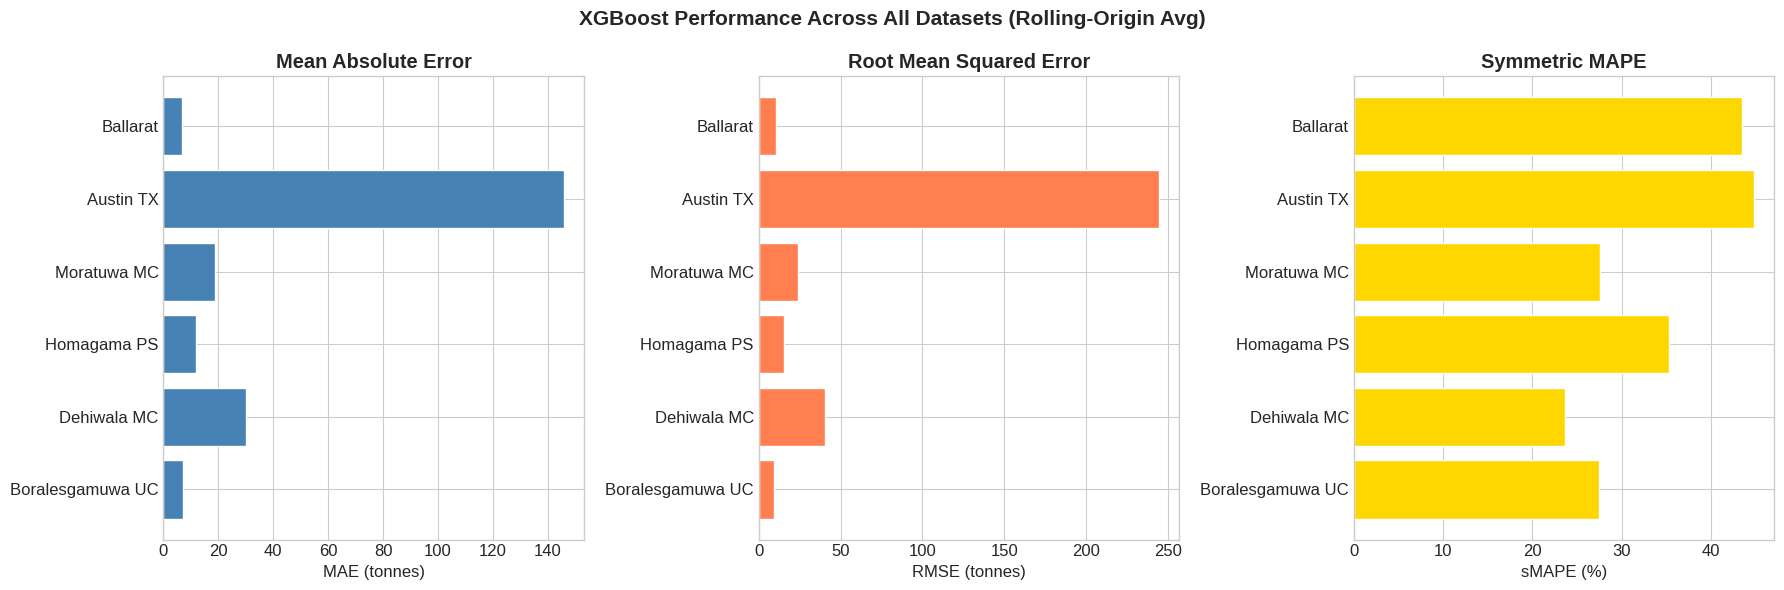

In [9]:
# --- Plot 201: XGBoost Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# sMAPE
axes[2].barh(short_names, results_df['smape'], color='gold', edgecolor='white')
axes[2].set_xlabel('sMAPE (%)')
axes[2].set_title('Symmetric MAPE', fontweight='bold')

plt.suptitle('XGBoost Performance Across All Datasets (Rolling-Origin Avg)', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '201_xgb_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()